Loaded CSV with 24 rows
Columns: ['dataset', 'pruning_method', 'sparsity', 'stored_precision', 'batch_size', 'runtime_precision', 'num_passes', 'images_processed', 'elapsed_s', 'throughput_imgs_per_s']...
Filtered to 12 rows with batch_size=8

Creating radar chart for Base baseline and derived optimizations
  - Base baseline (reference)
  - Quantized Base
  - KD methods using Base as teacher (Base→Small, Base→Tiny)
Baseline values for Base:
  Throughput: 104.09 imgs/s
  Energy: 2.90e-07 kWh/image
  RAM: 2384.18 MB
  Model Size: 982.16 MB
  Accuracy: 0.9877
  AUC: 0.999328

Max ratios for scaling (Base):
  Accuracy: 1.0000 (defined max)
  AUC: 1.000000 (defined max)
  Throughput ratio: 7.27x baseline
  Energy ratio: 5.99x (baseline/current)
  RAM ratio: 1.95x (baseline/current)
  ModelSize ratio: 92.64x (baseline/current)

Radar chart saved to: radar_chart_batch8_base.png


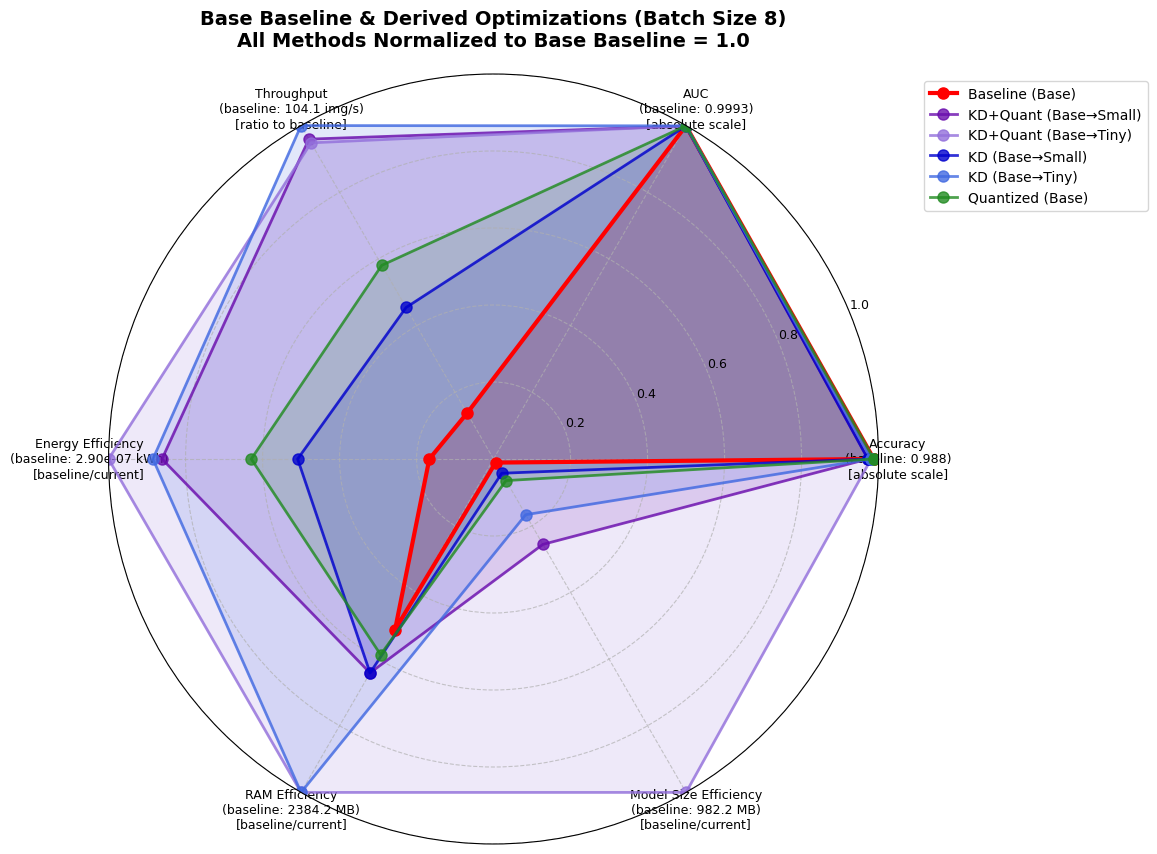


Base Model Performance Summary (Batch Size 8)
Model                          Accuracy     AUC          Throughput      Energy/img      RAM (MB)     Size (MB)   
------------------------------------------------------------------------------------------------------------------------
Baseline (Base)                0.9877       0.999328     104.09          2.90e-07        2384.2       982.2       
KD+Quant (Base→Small)          0.9725       0.998784     726.23          5.62e-08        1901.3       41.4        
KD+Quant (Base→Tiny)           0.9807       0.999199     717.79          4.84e-08        1219.9       10.6        
KD (Base→Small)                0.9725       0.998784     343.98          9.51e-08        1901.3       248.2       
KD (Base→Tiny)                 0.9807       0.999199     756.99          5.47e-08        1219.9       63.5        
Quantized (Base)               0.9877       0.999269     439.70          7.69e-08        2078.9       163.7       

Creating radar chart for S

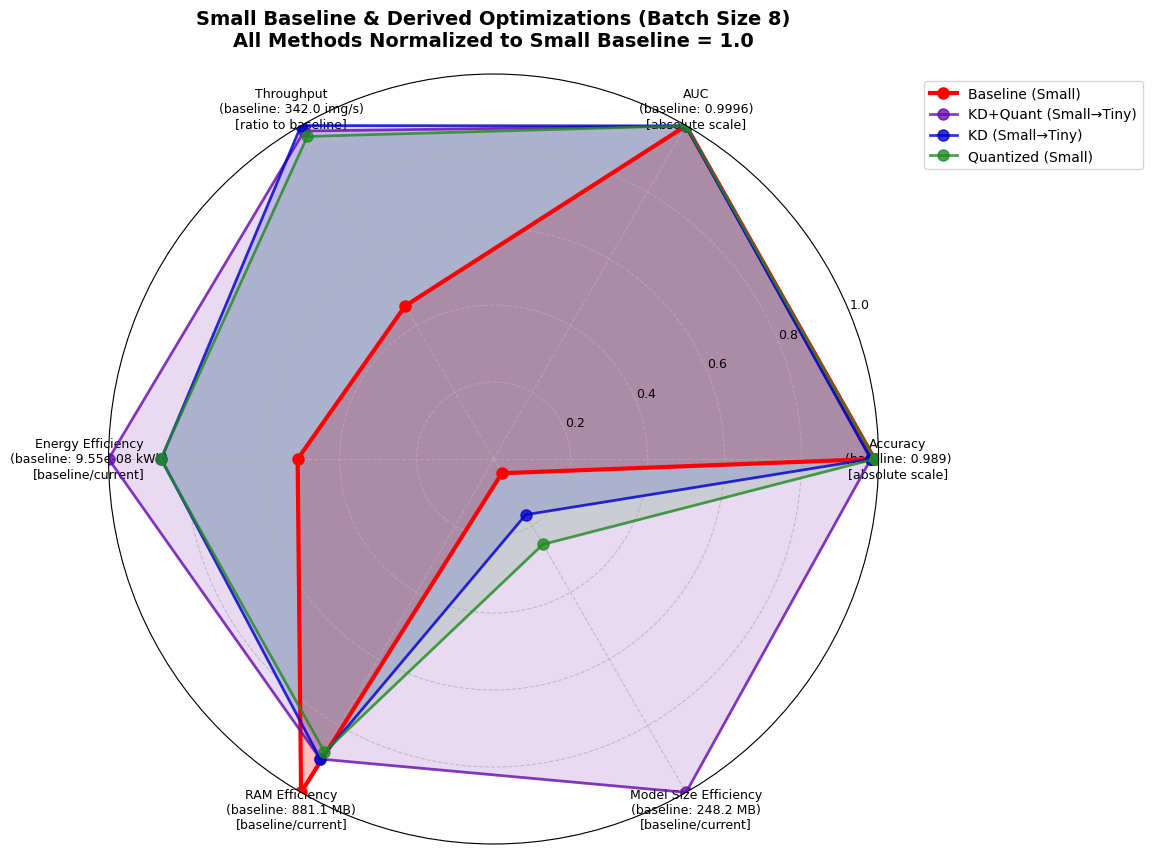


Small Model Performance Summary (Batch Size 8)
Model                          Accuracy     AUC          Throughput      Energy/img      RAM (MB)     Size (MB)   
------------------------------------------------------------------------------------------------------------------------
Baseline (Small)               0.9895       0.999596     342.05          9.55e-08        881.1        248.2       
KD+Quant (Small→Tiny)          0.9801       0.999091     732.75          4.86e-08        979.0        10.6        
KD (Small→Tiny)                0.9801       0.999091     744.87          5.63e-08        979.0        63.5        
Quantized (Small)              0.9895       0.999615     720.61          5.62e-08        1002.9       41.4        

Creating radar chart for Tiny baseline and derived optimizations
  - Tiny baseline (reference)
  - Quantized Tiny
Baseline values for Tiny:
  Throughput: 750.32 imgs/s
  Energy: 5.56e-08 kWh/image
  RAM: 388.48 MB
  Model Size: 63.44 MB
  Accuracy: 0.9874

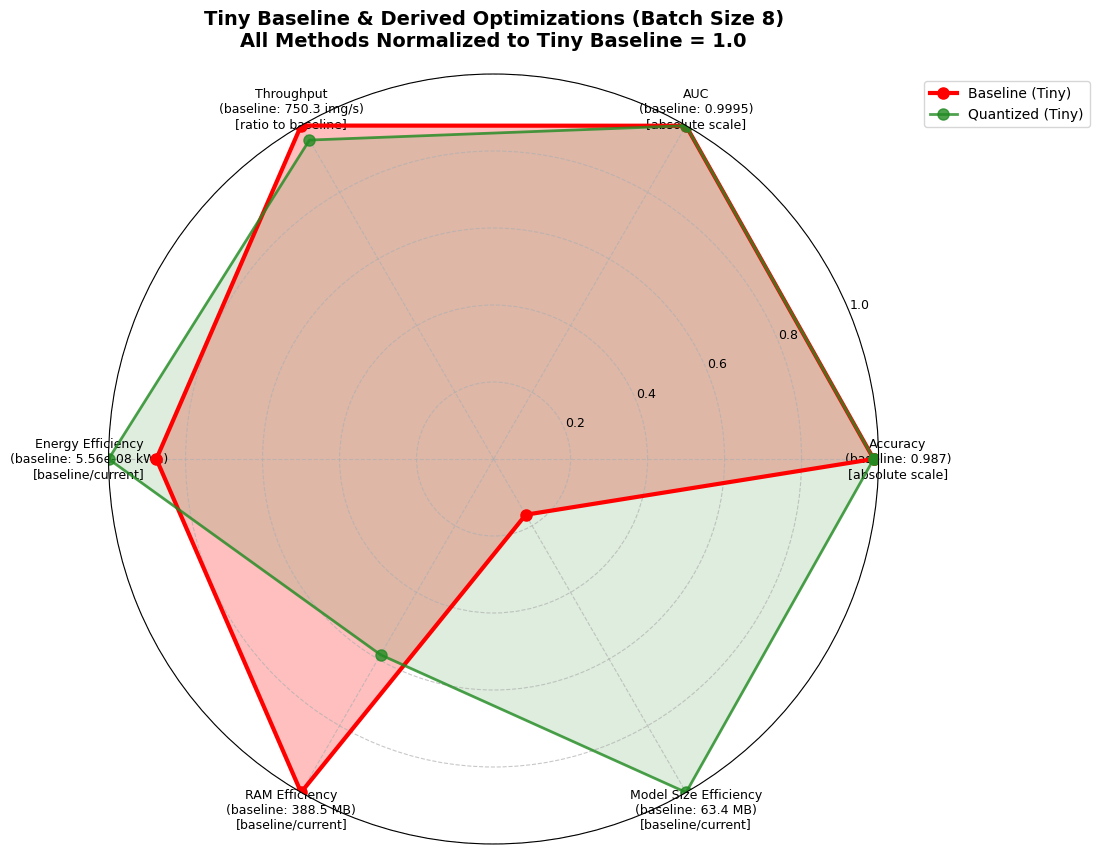


Tiny Model Performance Summary (Batch Size 8)
Model                          Accuracy     AUC          Throughput      Energy/img      RAM (MB)     Size (MB)   
------------------------------------------------------------------------------------------------------------------------
Baseline (Tiny)                0.9874       0.999537     750.32          5.56e-08        388.5        63.4        
Quantized (Tiny)               0.9874       0.999534     717.71          4.87e-08        661.6        10.6        


In [ ]:
"""
Radar Chart Visualization for Model Performance Comparison

This script creates three separate radar charts (Base, Small, Tiny models) comparing
performance metrics at batch size 8.

Usage in Jupyter Notebook:
    # At the top of your notebook cell:
    %matplotlib inline
    
    # Then run:
    from radar_chart import create_radar_chart
    create_radar_chart('path/to/your/bloodmnist_merged_results.csv', 
                       output_path='radar_chart_batch8.png')

Usage in Python script:
    python radar_chart.py
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi

def create_method_label(row):
    """Create display labels for each method variant."""
    method = row['pruning_method']
    precision = row['runtime_precision']
    variant = row['Variant']
    
    # Determine which baseline this is derived from (for grouping in charts)
    # BASE chart: Shows all optimizations derived from baseline_vit_base_patch16_224
    # SMALL chart: Shows all optimizations derived from baseline_vit_small_patch16_224
    # TINY chart: Shows all optimizations derived from baseline_vit_tiny_patch16_224
    
    if variant == 'baseline_vit_base_patch16_224' and precision == 'fp32':
        return 'Baseline (Base)', 'baseline', 0, 'Base'
    
    elif variant == 'baseline_vit_small_patch16_224' and method == 'baseline' and precision == 'fp32':
        return 'Baseline (Small)', 'baseline', 0, 'Small'
    
    elif variant == 'baseline_vit_tiny_patch16_224' and method == 'baseline' and precision == 'fp32':
        return 'Baseline (Tiny)', 'baseline', 0, 'Tiny'
    
    # Quantized versions - grouped by which baseline was quantized
    elif method == 'quantization' and precision == 'amp':
        if 'vit_base_patch' in variant:
            return 'Quantized (Base)', 'quantized', 1, 'Base'
        elif 'vit_small_patch' in variant:
            return 'Quantized (Small)', 'quantized', 1, 'Small'
        elif 'vit_tiny_patch' in variant:
            return 'Quantized (Tiny)', 'quantized', 1, 'Tiny'
    
    # Knowledge Distillation - grouped by TEACHER (source) model, not student
    elif method == 'kd' and precision == 'fp32':
        if 'base' in variant and 'small' in variant:
            # Teacher is base, so belongs to Base chart
            return 'KD (Base→Small)', 'kd', 2, 'Base'
        elif 'base' in variant and 'tiny' in variant:
            # Teacher is base, so belongs to Base chart
            return 'KD (Base→Tiny)', 'kd', 3, 'Base'
        elif 'small' in variant and 'tiny' in variant:
            # Teacher is small, so belongs to Small chart
            return 'KD (Small→Tiny)', 'kd', 2, 'Small'
        else:
            return 'KD', 'kd', 99, 'Unknown'
    
    # KD with quantization (hybrid) - grouped by TEACHER model
    elif method == 'kd' and precision == 'amp':
        if 'base' in variant and 'small' in variant:
            # Teacher is base, so belongs to Base chart
            return 'KD+Quant (Base→Small)', 'kd_quant', 4, 'Base'
        elif 'base' in variant and 'tiny' in variant:
            # Teacher is base, so belongs to Base chart
            return 'KD+Quant (Base→Tiny)', 'kd_quant', 5, 'Base'
        elif 'small' in variant and 'tiny' in variant:
            # Teacher is small, so belongs to Small chart
            return 'KD+Quant (Small→Tiny)', 'kd_quant', 3, 'Small'
        else:
            return 'KD+Quant', 'kd_quant', 99, 'Unknown'
    
    else:
        # Try to determine group from variant name
        if 'vit_base_patch' in variant:
            return f'{method} {precision}', 'other', 99, 'Base'
        elif 'vit_small_patch' in variant:
            return f'{method} {precision}', 'other', 99, 'Small'
        elif 'vit_tiny_patch' in variant:
            return f'{method} {precision}', 'other', 99, 'Tiny'
        else:
            return f'{method} {precision}', 'other', 99, 'Unknown'


def get_method_color(label):
    """Get color for each method label"""
    color_map = {
        # Baselines - red shades
        'Baseline (Base)': '#FF0000',
        'Baseline (Small)': '#FF0000',
        'Baseline (Tiny)': '#FF0000',
        
        # Quantized models - green shades  
        'Quantized (Base)': '#228B22',
        'Quantized (Small)': '#228B22',
        'Quantized (Tiny)': '#228B22',
        
        # KD methods - blue shades
        'KD (Base→Small)': '#0000CD',
        'KD (Base→Tiny)': '#4169E1',
        'KD (Small→Tiny)': '#0000CD',
        
        # KD+Quantization (hybrid) - purple shades
        'KD+Quant (Base→Small)': '#6A0DAD',
        'KD+Quant (Base→Tiny)': '#9370DB',
        'KD+Quant (Small→Tiny)': '#6A0DAD',
    }
    return color_map.get(label, '#333333')


def create_radar_chart(csv_path, output_path='radar_chart.png'):
    """
    Create three separate radar charts (Base, Small, Tiny baselines)
    
    Each chart shows a baseline and ALL optimizations derived from it:
    - Base chart: baseline_vit_base_patch16_224 + quantized + KD methods using Base as teacher
    - Small chart: baseline_vit_small_patch16_224 + quantized + KD methods using Small as teacher  
    - Tiny chart: baseline_vit_tiny_patch16_224 + quantized
    
    This grouping allows you to answer: "If I start with baseline X, which optimization 
    technique gives me the best performance?"
    
    - Uses batch size 8 only
    - Metrics: accuracy, auc, throughput, energy_kWh_per_image, PeakRAM_MB, ModelSizeMB
    - Each baseline normalized to 1.0 on all axes
    """
    
    # Read the CSV file (comma-separated)
    df = pd.read_csv(csv_path)
    
    print(f"Loaded CSV with {len(df)} rows")
    print(f"Columns: {df.columns.tolist()[:10]}...")  # Show first 10 columns
    
    # Check if batch_size column exists
    if 'batch_size' not in df.columns:
        print(f"\nAvailable columns: {df.columns.tolist()}")
        raise KeyError("'batch_size' column not found in CSV. Please check the file format.")
    
    # Filter for batch size 8
    df = df[df['batch_size'] == 8].copy()
    print(f"Filtered to {len(df)} rows with batch_size=8")
    
    # Add method labels and model size
    df[['method_label', 'method_group', 'sort_order', 'model_size']] = df.apply(
        lambda row: pd.Series(create_method_label(row)), axis=1
    )
    
    # Safety check: Convert percentages to decimals if needed
    if df['Acc'].max() > 1.5:
        print("Converting Accuracy from percentage to decimal...")
        df['Acc'] = df['Acc'] / 100.0
    if df['AUC'].max() > 1.5:
        print("Converting AUC from percentage to decimal...")
        df['AUC'] = df['AUC'] / 100.0
    
    # Safety check: Handle zero or NaN values in energy, RAM, and ModelSize
    df['energy_kWh_per_image'] = df['energy_kWh_per_image'].replace(0, np.nan)
    df['PeakRAM_MB'] = df['PeakRAM_MB'].replace(0, np.nan)
    df['ModelSizeMB'] = df['ModelSizeMB'].replace(0, np.nan)
    
    # Define the metrics we want to plot (6 metrics)
    metrics = ['Acc', 'AUC', 'throughput_imgs_per_s', 'energy_kWh_per_image', 'PeakRAM_MB', 'ModelSizeMB']
    metric_labels = ['Accuracy', 'AUC', 'Throughput\n(imgs/s)', 'Energy\n(lower is better)', 'Peak RAM\n(lower is better)', 'Model Size\n(lower is better)']
    
    # Process each model size separately
    model_sizes = ['Base', 'Small', 'Tiny']
    
    for model_size in model_sizes:
        print(f"\n{'='*60}")
        print(f"Creating radar chart for {model_size} baseline and derived optimizations")
        print(f"  - {model_size} baseline (reference)")
        print(f"  - Quantized {model_size}")
        if model_size == 'Base':
            print(f"  - KD methods using {model_size} as teacher (Base→Small, Base→Tiny)")
        elif model_size == 'Small':
            print(f"  - KD methods using {model_size} as teacher (Small→Tiny)")
        print(f"{'='*60}")
        
        # Filter data for this model size
        size_df = df[df['model_size'] == model_size].copy()
        
        if size_df.empty:
            print(f"No data for {model_size} models, skipping...")
            continue
        
        # Get the baseline for this size (handle duplicates by taking best accuracy)
        if model_size == 'Base':
            baseline_candidates = size_df[size_df['method_label'] == 'Baseline (Base)']
        elif model_size == 'Small':
            baseline_candidates = size_df[size_df['method_label'] == 'Baseline (Small)']
        else:  # Tiny
            baseline_candidates = size_df[size_df['method_label'] == 'Baseline (Tiny)']
        
        if baseline_candidates.empty:
            print(f"No baseline found for {model_size} models, skipping...")
            continue
        
        # If multiple baselines, take the one with highest accuracy
        baseline = baseline_candidates.sort_values('Acc', ascending=False).iloc[0]
        
        print(f"Baseline values for {model_size}:")
        print(f"  Throughput: {baseline['throughput_imgs_per_s']:.2f} imgs/s")
        print(f"  Energy: {baseline['energy_kWh_per_image']:.2e} kWh/image")
        print(f"  RAM: {baseline['PeakRAM_MB']:.2f} MB")
        print(f"  Model Size: {baseline['ModelSizeMB']:.2f} MB")
        print(f"  Accuracy: {baseline['Acc']:.4f}")
        print(f"  AUC: {baseline['AUC']:.6f}")
        
        # Calculate max values for scaling (within this model size)
        max_acc = 1.0  # Defined maximum
        max_auc = 1.0  # Defined maximum
        
        # CRITICAL: Normalization approach for "lower is better" metrics
        # We use baseline/current ratios instead of 1/value to:
        # 1. Make baseline = 1.0 by definition (intuitive reference point)
        # 2. Avoid numerical instability from small values (e.g., 1/1e-7)
        # 3. Provide meaningful interpretation (2.0 = half the energy/RAM/size)
        # 4. Prevent scaling artifacts where best model dominates
        
        # For throughput, energy, RAM, and ModelSize: calculate ratios relative to baseline
        # This makes baseline = 1.0 by definition
        size_df['throughput_ratio'] = size_df['throughput_imgs_per_s'] / baseline['throughput_imgs_per_s']
        size_df['energy_ratio'] = baseline['energy_kWh_per_image'] / size_df['energy_kWh_per_image']  # inverted: lower energy = higher ratio
        size_df['ram_ratio'] = baseline['PeakRAM_MB'] / size_df['PeakRAM_MB']  # inverted: lower RAM = higher ratio
        size_df['modelsize_ratio'] = baseline['ModelSizeMB'] / size_df['ModelSizeMB']  # inverted: smaller model = higher ratio
        
        # Get max ratios for scaling (so best model reaches ~1.0)
        max_throughput_ratio = size_df['throughput_ratio'].max()
        max_energy_ratio = size_df['energy_ratio'].max()
        max_ram_ratio = size_df['ram_ratio'].max()
        max_modelsize_ratio = size_df['modelsize_ratio'].max()
        
        print(f"\nMax ratios for scaling ({model_size}):")
        print(f"  Accuracy: {max_acc:.4f} (defined max)")
        print(f"  AUC: {max_auc:.6f} (defined max)")
        print(f"  Throughput ratio: {max_throughput_ratio:.2f}x baseline")
        print(f"  Energy ratio: {max_energy_ratio:.2f}x (baseline/current)")
        print(f"  RAM ratio: {max_ram_ratio:.2f}x (baseline/current)")
        print(f"  ModelSize ratio: {max_modelsize_ratio:.2f}x (baseline/current)")
        
        # Prepare data for each model variant in this size
        models_to_plot = []
        
        for _, row in size_df.iterrows():
            label = row['method_label']
            
            # Get raw values
            acc = row['Acc']
            auc = row['AUC']
            throughput = row['throughput_imgs_per_s']
            energy = row['energy_kWh_per_image']
            ram = row['PeakRAM_MB']
            modelsize = row['ModelSizeMB']
            
            # Skip if critical values are missing
            if pd.isna(acc) or pd.isna(auc) or pd.isna(throughput) or pd.isna(energy) or pd.isna(ram) or pd.isna(modelsize):
                print(f"  Skipping {label} due to missing values")
                continue
            
            # Normalize each metric
            normalized_values = []
            
            # 1. Accuracy - scale to max of 1.0
            normalized_values.append(acc / max_acc)
            
            # 2. AUC - scale to max of 1.0
            normalized_values.append(auc / max_auc)
            
            # 3. Throughput - ratio to baseline, scaled by max ratio
            throughput_ratio = throughput / baseline['throughput_imgs_per_s']
            normalized_values.append(min(throughput_ratio / max_throughput_ratio, 1.0))
            
            # 4. Energy - baseline/current ratio (higher = better/less energy), scaled by max ratio
            energy_ratio = baseline['energy_kWh_per_image'] / energy
            normalized_values.append(min(energy_ratio / max_energy_ratio, 1.0))
            
            # 5. RAM - baseline/current ratio (higher = better/less RAM), scaled by max ratio
            ram_ratio = baseline['PeakRAM_MB'] / ram
            normalized_values.append(min(ram_ratio / max_ram_ratio, 1.0))
            
            # 6. ModelSize - baseline/current ratio (higher = better/smaller model), scaled by max ratio
            modelsize_ratio = baseline['ModelSizeMB'] / modelsize
            normalized_values.append(min(modelsize_ratio / max_modelsize_ratio, 1.0))
            
            models_to_plot.append({
                'label': label,
                'values': normalized_values,
                'raw_values': {
                    'Acc': acc,
                    'AUC': auc,
                    'Throughput': throughput,
                    'Energy': energy,
                    'RAM': ram,
                    'ModelSize': modelsize
                }
            })
        
        # Create the radar chart
        num_vars = len(metrics)
        
        # Compute angle for each axis
        angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
        angles += angles[:1]  # Complete the circle
        
        # Initialize the plot
        fig, ax = plt.subplots(figsize=(12, 10), subplot_kw=dict(projection='polar'))
        
        # Define colors for different models
        colors = plt.cm.tab10(np.linspace(0, 1, len(models_to_plot)))
        
        # Plot each model
        for idx, model_data in enumerate(models_to_plot):
            values = model_data['values']
            values += values[:1]  # Complete the circle
            
            # Make baseline thicker and more prominent
            linewidth = 3 if 'Baseline' in model_data['label'] else 2
            alpha_line = 1.0 if 'Baseline' in model_data['label'] else 0.8
            alpha_fill = 0.25 if 'Baseline' in model_data['label'] else 0.15
            
            color = get_method_color(model_data['label'])
            
            ax.plot(angles, values, 'o-', linewidth=linewidth, label=model_data['label'], 
                    color=color, markersize=8, alpha=alpha_line)
            ax.fill(angles, values, alpha=alpha_fill, color=color)
        
        # Set the labels for each axis with baseline values
        ax.set_xticks(angles[:-1])
        
        # Create labels with baseline values
        baseline_raw = baseline
        axis_labels = []
        for i, (metric_label, metric_key) in enumerate(zip(metric_labels, ['Acc', 'AUC', 'throughput_imgs_per_s', 'energy_kWh_per_image', 'PeakRAM_MB', 'ModelSizeMB'])):
            baseline_val = baseline_raw[metric_key]
            if metric_key == 'Acc':
                axis_labels.append(f"{metric_label}\n(baseline: {baseline_val:.3f})\n[absolute scale]")
            elif metric_key == 'AUC':
                axis_labels.append(f"{metric_label}\n(baseline: {baseline_val:.4f})\n[absolute scale]")
            elif metric_key == 'throughput_imgs_per_s':
                axis_labels.append(f"Throughput\n(baseline: {baseline_val:.1f} img/s)\n[ratio to baseline]")
            elif metric_key == 'energy_kWh_per_image':
                axis_labels.append(f"Energy Efficiency\n(baseline: {baseline_val:.2e} kWh)\n[baseline/current]")
            elif metric_key == 'PeakRAM_MB':
                axis_labels.append(f"RAM Efficiency\n(baseline: {baseline_val:.1f} MB)\n[baseline/current]")
            else:  # ModelSizeMB
                axis_labels.append(f"Model Size Efficiency\n(baseline: {baseline_val:.1f} MB)\n[baseline/current]")
        
        ax.set_xticklabels(axis_labels, size=9)
        
        # Set y-axis limits - all metrics scaled to 0-1 range
        ax.set_ylim(0, 1.0)
        ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
        ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], size=9)
        ax.grid(True, linestyle='--', alpha=0.7)
        
        # Add a title
        plt.title(f'{model_size} Baseline & Derived Optimizations (Batch Size 8)\nAll Methods Normalized to {model_size} Baseline = 1.0',
                  size=14, weight='bold', pad=20)
        
        # Add legend with better positioning
        plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1.0), fontsize=10)
        
        # Save the figure first
        size_output_path = output_path.replace('.png', f'_{model_size.lower()}.png')
        plt.savefig(size_output_path, dpi=300, bbox_inches='tight')
        print(f"\nRadar chart saved to: {size_output_path}")
        
        # Display in Jupyter notebook
        plt.show()
        
        # Close to free memory
        plt.close()
        
        # Print summary table for this model size
        print(f"\n{model_size} Model Performance Summary (Batch Size 8)")
        print("="*120)
        print(f"{'Model':<30} {'Accuracy':<12} {'AUC':<12} {'Throughput':<15} {'Energy/img':<15} {'RAM (MB)':<12} {'Size (MB)':<12}")
        print("-"*120)
        
        for model in models_to_plot:
            raw = model['raw_values']
            print(f"{model['label']:<30} {raw['Acc']:<12.4f} {raw['AUC']:<12.6f} "
                  f"{raw['Throughput']:<15.2f} {raw['Energy']:<15.2e} {raw['RAM']:<12.1f} {raw['ModelSize']:<12.1f}")
        print("="*120)


if __name__ == "__main__":
    # Update this path to your CSV file location
    csv_path = "/Users/arihangupta/Downloads/pruning_project_data/Vision/merged_results/bloodmnist_merged_results.csv"  # Change this to your file path
    
    # Generate the radar chart
    create_radar_chart(csv_path, output_path='radar_chart_batch8.png')